In [1]:
import pandas as pd

In [4]:
df = pd.read_parquet("../data/raw/esios/demanda_real/demanda_real_2025.parquet")

#Validar que no hay duplicados

df.duplicated(subset=["datetime"]).sum()

np.int64(0)

In [6]:
#Ver rango de fechas

df["datetime"].min(), df["datetime"].max()

(Timestamp('2024-12-31 23:00:00+0000', tz='UTC'),
 Timestamp('2025-12-30 23:00:00+0000', tz='UTC'))

In [7]:
#Valores nulos

df.isnull().sum()

datetime     0
value        0
geo_id       0
geo_name     0
fecha        0
hora         0
año          0
mes          0
indicador    0
dtype: int64

In [10]:
#Validar continuidad temporal

df = df.sort_values("datetime")

df["diff"] = df["datetime"].diff()

df["diff"].value_counts().head()

diff
0 days 01:00:00    8736
Name: count, dtype: int64

In [11]:
#Detectar valores raros (outliers)

df["value"].describe()

count      8737.000000
mean     325897.302621
std       56749.452001
min           0.000000
25%      283595.000000
50%      326706.000000
75%      367507.000000
max      476062.000000
Name: value, dtype: float64

In [15]:
import matplotlib.pyplot as plt


<Axes: >

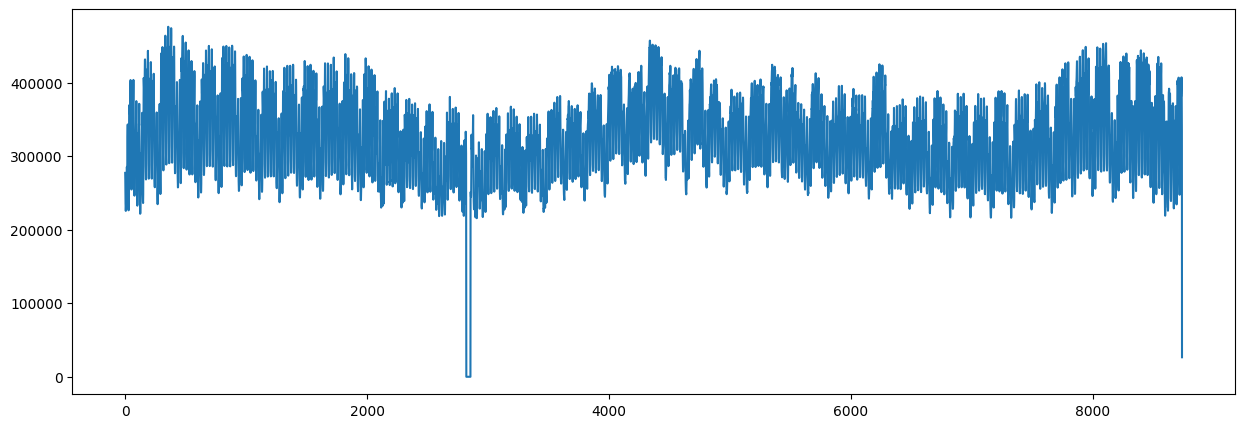

In [16]:
df["value"].plot(figsize=(15,5))

<Axes: title={'center': 'Demanda promedio por hora'}, xlabel='hora'>

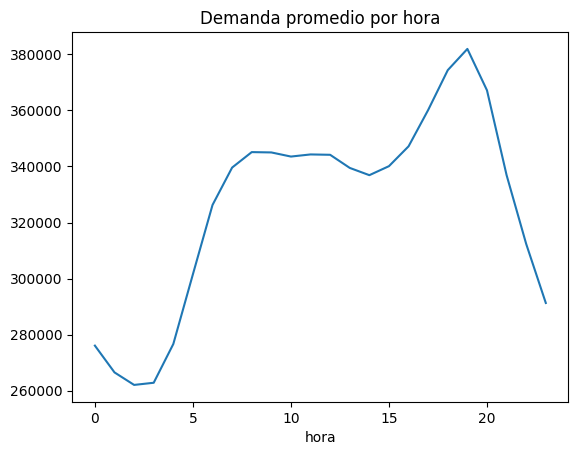

In [18]:
#Estacionalidad

df.groupby("hora")["value"].mean().plot(title="Demanda promedio por hora")

<Axes: title={'center': 'Demanda promedio por mes'}, xlabel='mes'>

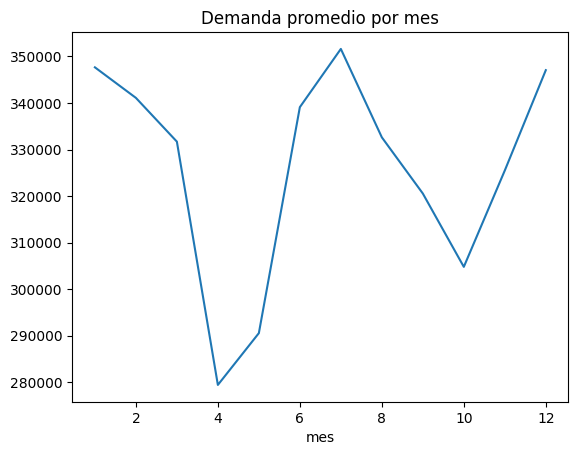

In [20]:
#Patrón por mes

df.groupby("mes")["value"].mean().plot(title="Demanda promedio por mes")

<Axes: title={'center': 'Demanda por día de semana'}, xlabel='dia_semana'>

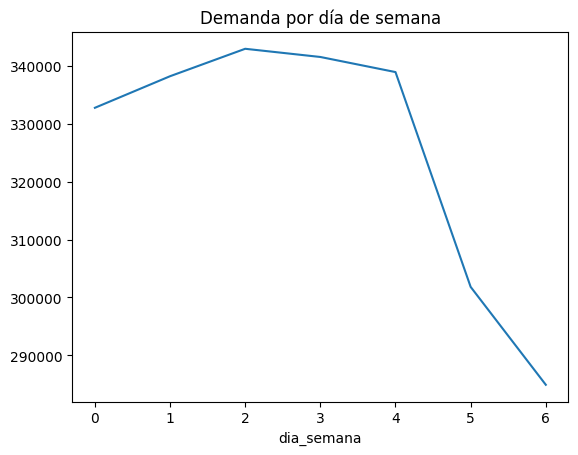

In [21]:
#Día de la semana

df["dia_semana"] = df["datetime"].dt.dayofweek

df.groupby("dia_semana")["value"].mean().plot(title="Demanda por día de semana")

In [22]:
#Outliers

df[df["value"] < 50000]

,datetime,value,geo_id,geo_name,fecha,hora,año,mes,indicador,diff,dia_semana
2820,2025-04-28 11:00:00+00:00,0.0,8741,Península,2025-04-28,11,2025,4,demanda_real,0 days 01:00:00,0
2821,2025-04-28 12:00:00+00:00,0.0,8741,Península,2025-04-28,12,2025,4,demanda_real,0 days 01:00:00,0
2822,2025-04-28 13:00:00+00:00,0.0,8741,Península,2025-04-28,13,2025,4,demanda_real,0 days 01:00:00,0
2823,2025-04-28 14:00:00+00:00,0.0,8741,Península,2025-04-28,14,2025,4,demanda_real,0 days 01:00:00,0
2824,2025-04-28 15:00:00+00:00,0.0,8741,Península,2025-04-28,15,2025,4,demanda_real,0 days 01:00:00,0
2825,2025-04-28 16:00:00+00:00,0.0,8741,Península,2025-04-28,16,2025,4,demanda_real,0 days 01:00:00,0
2826,2025-04-28 17:00:00+00:00,0.0,8741,Península,2025-04-28,17,2025,4,demanda_real,0 days 01:00:00,0
2827,2025-04-28 18:00:00+00:00,0.0,8741,Península,2025-04-28,18,2025,4,demanda_real,0 days 01:00:00,0
2828,2025-04-28 19:00:00+00:00,0.0,8741,Península,2025-04-28,19,2025,4,demanda_real,0 days 01:00:00,0
2829,2025-04-28 20:00:00+00:00,0.0,8741,Península,2025-04-28,20,2025,4,demanda_real,0 days 01:00:00,0


In [23]:
df["es_outlier"] = df["value"] < 50000

In [24]:
df[df["es_outlier"]].sort_values("datetime")

,datetime,value,geo_id,geo_name,fecha,hora,año,mes,indicador,diff,dia_semana,es_outlier
2820,2025-04-28 11:00:00+00:00,0.0,8741,Península,2025-04-28,11,2025,4,demanda_real,0 days 01:00:00,0,True
2821,2025-04-28 12:00:00+00:00,0.0,8741,Península,2025-04-28,12,2025,4,demanda_real,0 days 01:00:00,0,True
2822,2025-04-28 13:00:00+00:00,0.0,8741,Península,2025-04-28,13,2025,4,demanda_real,0 days 01:00:00,0,True
2823,2025-04-28 14:00:00+00:00,0.0,8741,Península,2025-04-28,14,2025,4,demanda_real,0 days 01:00:00,0,True
2824,2025-04-28 15:00:00+00:00,0.0,8741,Península,2025-04-28,15,2025,4,demanda_real,0 days 01:00:00,0,True
2825,2025-04-28 16:00:00+00:00,0.0,8741,Península,2025-04-28,16,2025,4,demanda_real,0 days 01:00:00,0,True
2826,2025-04-28 17:00:00+00:00,0.0,8741,Península,2025-04-28,17,2025,4,demanda_real,0 days 01:00:00,0,True
2827,2025-04-28 18:00:00+00:00,0.0,8741,Península,2025-04-28,18,2025,4,demanda_real,0 days 01:00:00,0,True
2828,2025-04-28 19:00:00+00:00,0.0,8741,Península,2025-04-28,19,2025,4,demanda_real,0 days 01:00:00,0,True
2829,2025-04-28 20:00:00+00:00,0.0,8741,Península,2025-04-28,20,2025,4,demanda_real,0 days 01:00:00,0,True
